In [1]:
!pip install transformers==4.35.2 torch==2.2.2 matplotlib

In [2]:
from google.colab import files
uploaded = files.upload()

Saving env.py to env (1).py


In [8]:
import torch
import random
import numpy as np
# 🔥 ADD SEEDS HERE (RIGHT AFTER IMPORTS)
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

from env import TaskEnv

# Load model
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
def generate_tasks():
    return [
        {"id": i, "priority": random.randint(1, 5), "duration": random.randint(1, 5)}
        for i in range(3)
    ]

def state_to_prompt(state):
    prompt = "You are a task scheduler.\n\nTasks:\n"
    for i, task in enumerate(state):
        prompt += f"{i}: priority={task['priority']}, duration={task['duration']}\n"
    prompt += "\nChoose the task index to execute next:\n"
    return prompt

def response_to_action(response):
    import re
    numbers = re.findall(r"\d+", response)
    return int(numbers[0]) if numbers else 0

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

rewards_history = []

for episode in range(30):

    tasks = generate_tasks()
    env = TaskEnv(tasks)

    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)
        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=True,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        logits = model(**inputs).logits
        log_probs = torch.nn.functional.log_softmax(logits[:, -1, :], dim=-1)

        chosen_token = outputs[0][-1]
        log_prob = log_probs[0, chosen_token]

        loss = -(reward / 10.0) * log_prob

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    rewards_history.append(total_reward)
    print(f"Episode {episode} | Reward: {total_reward}")

Episode 0 | Reward: 5.7
Episode 1 | Reward: 9.3
Episode 2 | Reward: 8.7
Episode 3 | Reward: 7.8
Episode 4 | Reward: 6.8
Episode 5 | Reward: 10.799999999999999
Episode 6 | Reward: 8.9
Episode 7 | Reward: 8.7


KeyboardInterrupt: 

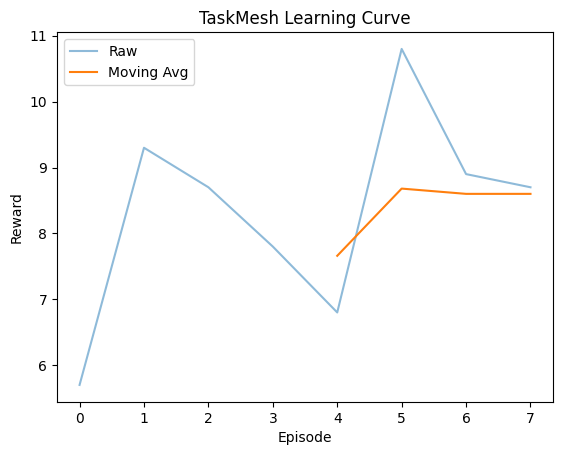

In [6]:
window = 5
moving_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')

plt.plot(rewards_history, alpha=0.5, label="Raw")
plt.plot(range(window-1, len(rewards_history)), moving_avg, label="Moving Avg")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("TaskMesh Learning Curve")
plt.legend()
plt.show()

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

rewards_history = []

for episode in range(13):

    tasks = generate_tasks()
    env = TaskEnv(tasks)

    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        prompt = state_to_prompt(state)
        inputs = tokenizer(prompt, return_tensors="pt")

        outputs = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=True,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = full_text[len(prompt):]

        action = response_to_action(response)
        action = min(action, len(state)-1)

        next_state, reward, done = env.step(action)

        logits = model(**inputs).logits
        log_probs = torch.nn.functional.log_softmax(logits[:, -1, :], dim=-1)

        chosen_token = outputs[0][-1]
        log_prob = log_probs[0, chosen_token]

        loss = -(reward / 10.0) * log_prob

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_reward += reward
        state = next_state

    rewards_history.append(total_reward)
    print(f"Episode {episode} | Reward: {total_reward}")

Episode 0 | Reward: 9.5
Episode 1 | Reward: 6.7
Episode 2 | Reward: 13.0
Episode 3 | Reward: 11.7
Episode 4 | Reward: 7.6
Episode 5 | Reward: 10.7
Episode 6 | Reward: 10.100000000000001
Episode 7 | Reward: 16.1
Episode 8 | Reward: 7.7
Episode 9 | Reward: 11.1
Episode 10 | Reward: 9.299999999999999
Episode 11 | Reward: 10.7
Episode 12 | Reward: 8.1
